## Problem: When arriving at the Doan Hall stop, the bus is already full from the UH stop. 

### Goals:

- Break down boardings and alightings by stop (UH and Doan) in 30 minute intervals 
- Sample data from approximately 4/1/2026 - 4/14/2026
- 9am timeframe investigated here.

---

Ultimate goal is to determine if full busses are coming TO Doan FROM UH and pinpoint the timeframe of when the problem is occuring.

---

**NOTES:**
- This is limited by accuracy of the APCs
- No data exists for people 'waiting' for a bus to my knowledge
- This is descriptive of past events and does not necessarily predict future patterns
- I cannot say why busses are overcrowding, only can determine if and when

In [1]:
# Should only have to run 1x here/
from modules import busstate_processing as bp

# Should contain data from 4/1/2026 to present 4/16/2026
bp.busstate_processing(year = "26", month = "04", current_dir = "K:/AP/TTM/Data/WMC_Dashboard/") #stored initial in /analysis_data if needed in future

ModuleNotFoundError: No module named 'modules'

In [2]:
import pandas as pd
# original data (4/1/2026 - 4/15/2026) is additionally stored in K:/AP/TTM/Data/WMC_Dashboard/analysis_data
import sys
import os

# go up one level from notebook folder
sys.path.append(os.path.abspath(".."))
from modules import med_center_dashboard as mcd

# ok - busstate data is stored in K:/AP/TTM/Data/WMC_Dashboard/analysis_data
# this contains from 4/1/2026 to present

apr_df = pd.read_csv("K:/AP/TTM/Data/WMC_Dashboard/analysis_data/2026-APR-busstate.csv")

apr_mc_df = mcd.process_mc_busstate(year = "2026",month = "APR")

apr_mc_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18560 entries, 0 to 18559
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype          
---  ------      --------------  -----          
 0   BUS_ID      18560 non-null  int64          
 1   DATE        18560 non-null  datetime64[us] 
 2   COUNT       18560 non-null  int64          
 3   STOP_ID     18560 non-null  int64          
 4   BOARDINGS   18560 non-null  int64          
 5   ALIGHTINGS  18560 non-null  int64          
 6   LOAD        18560 non-null  int64          
 7   RUN_ID      18560 non-null  float64        
 8   DEST        18560 non-null  str            
 9   ARRIVAL     18560 non-null  datetime64[us] 
 10  DEPARTURE   18560 non-null  datetime64[us] 
 11  DWELL       18560 non-null  timedelta64[us]
 12  HOUR        18560 non-null  int32          
 13  MINUTE      18560 non-null  int32          
dtypes: datetime64[us](3), float64(1), int32(2), int64(6), str(1), timedelta64[us](1)
memory usage: 1.8 MB


In [3]:
# cut down to only doan 37 and UH 401
# should now only have info for UH and Doan stops
uh_doan_apr_mc_df = apr_mc_df[(apr_mc_df['STOP_ID'] == 401) | (apr_mc_df['STOP_ID'] == 37)]

uh_doan_apr_mc_df

,BUS_ID,DATE,COUNT,STOP_ID,BOARDINGS,ALIGHTINGS,LOAD,RUN_ID,DEST,ARRIVAL,DEPARTURE,DWELL,HOUR,MINUTE
4,1303,2026-04-01,5,401,22,2,27,1503.0,MC,1900-01-01 14:06:59,1900-01-01 14:08:18,0 days 00:01:19,14,6
5,1303,2026-04-01,6,37,13,8,32,1503.0,MC,1900-01-01 14:08:51,1900-01-01 14:11:46,0 days 00:02:55,14,8
10,1303,2026-04-01,11,401,11,13,15,1503.0,MC,1900-01-01 14:30:21,1900-01-01 14:32:22,0 days 00:02:01,14,30
11,1303,2026-04-01,12,37,8,7,14,1503.0,MC,1900-01-01 14:32:57,1900-01-01 14:34:21,0 days 00:01:24,14,32
16,1303,2026-04-01,17,401,3,7,5,1503.0,MC,1900-01-01 14:53:41,1900-01-01 14:54:31,0 days 00:00:50,14,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18545,2503,2026-04-14,18536,37,6,1,11,1507.0,MC,1900-01-01 19:08:34,1900-01-01 19:11:40,0 days 00:03:06,19,8
18550,2503,2026-04-14,18541,401,38,2,38,1507.0,MC,1900-01-01 19:28:42,1900-01-01 19:30:23,0 days 00:01:41,19,28
18551,2503,2026-04-14,18542,37,5,1,42,1507.0,MC,1900-01-01 19:30:54,1900-01-01 19:33:39,0 days 00:02:45,19,30
18556,2503,2026-04-14,18547,401,6,1,5,1507.0,MC,1900-01-01 19:49:48,1900-01-01 19:50:46,0 days 00:00:58,19,49


In [4]:
# import visualization libraries
%pip install seaborn matplotlib

import seaborn as sns
import matplotlib.pyplot as plt 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Side by side stop comparison

In [5]:
# cut down sample data to date, time of arrival, stop, boardings, and alightings 
temp = uh_doan_apr_mc_df[['DATE', 'ARRIVAL', 'STOP_ID', 'BOARDINGS', 'ALIGHTINGS']]

# combine date and arrival time to single col
temp['TIME'] = pd.to_datetime(temp['DATE'].astype(str) + ' ' + temp['ARRIVAL'].dt.time.astype(str))
temp.drop(['DATE', 'ARRIVAL'], axis=1, inplace=True)

# break apart timeframes into 30 min intervals - not keeping date specifically
# temp['BUCKET'] = temp['TIME'].dt.floor('30Min').dt.time

# cut down bucket to hr/min, dont need sec
# true 30-min bucket, no date shown
temp['BUCKET'] = temp['TIME'].dt.floor('30min').dt.strftime('%H:%M')

# create a 'net' colum as boardings - alightings
# directional, negative indicates bus 'emptying' passengers, positive indicates bus 'filling' passengers
mc_df = temp.copy()
mc_df['NET'] = mc_df['BOARDINGS'] - mc_df['ALIGHTINGS'] # net indicates PER STOP

# this did NOT work at all
# # sort by stop and time and get a "running load"?
# mc_df.sort_values(['TIME'], inplace=True)
# mc_df['RUNNING_LOAD'] = mc_df.groupby('STOP_ID')['NET'].cumsum()

mc_df

,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,BUCKET,NET
4,401,22,2,2026-04-01 14:06:59,14:00,20
5,37,13,8,2026-04-01 14:08:51,14:00,5
10,401,11,13,2026-04-01 14:30:21,14:30,-2
11,37,8,7,2026-04-01 14:32:57,14:30,1
16,401,3,7,2026-04-01 14:53:41,14:30,-4
...,...,...,...,...,...,...
18545,37,6,1,2026-04-14 19:08:34,19:00,5
18550,401,38,2,2026-04-14 19:28:42,19:00,36
18551,37,5,1,2026-04-14 19:30:54,19:30,4
18556,401,6,1,2026-04-14 19:49:48,19:30,5


In [6]:
# Summary stats of the dataset I am working with here
mc_df.describe()

,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,NET
count,6499.000000,6499.000000,6499.000000,6499,6499.000000
mean,217.403754,5.104324,5.152023,2026-04-08 10:11:08.411448,-0.047700
min,37.000000,0.000000,0.000000,2026-04-01 00:02:29,-41.000000
25%,37.000000,0.000000,0.000000,2026-04-03 17:43:49,-6.000000
50%,37.000000,2.000000,2.000000,2026-04-08 11:51:42,0.000000
75%,401.000000,7.000000,8.000000,2026-04-13 06:02:28.500000,5.000000
max,401.000000,53.000000,42.000000,2026-04-16 04:54:11,52.000000
std,182.007003,7.347645,6.549053,NaN,10.704926


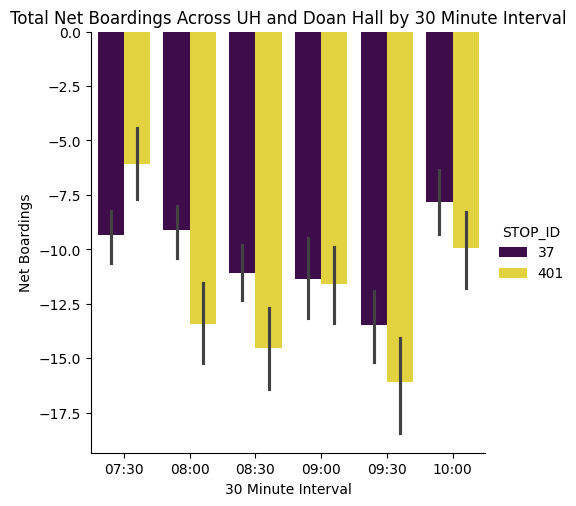

In [7]:
sns.set_palette("viridis_r")

# cut down sample data to doan hall and uh stops separately
# cut down to 1:30pm - 4:30pm for a buffer
mc_df = mc_df[(mc_df['TIME'].dt.time > pd.to_datetime('07:30').time()) & (mc_df['TIME'].dt.time <= pd.to_datetime('10:30').time())]
mc_df = mc_df.sort_values(by='TIME')

uh_df = mc_df[mc_df['STOP_ID'] == 401]
doan_df = mc_df[mc_df['STOP_ID'] == 37]


plot = sns.catplot(
    data = mc_df,
    x = 'BUCKET',
    y = 'NET',
    hue = 'STOP_ID',
    kind = 'bar',
    palette = "viridis"
)
plot.set(title = "Total Net Boardings Across UH and Doan Hall by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Net Boardings")
plt.show()

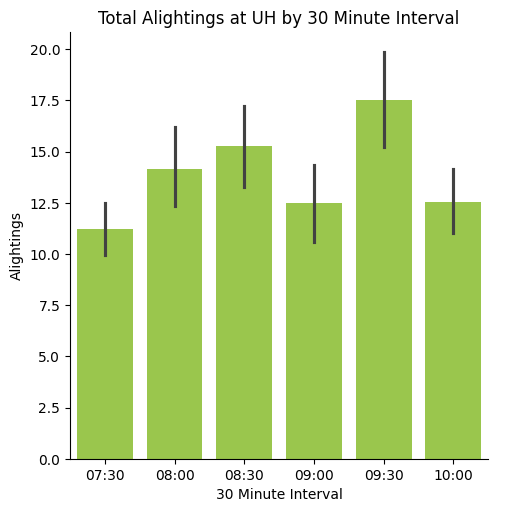

In [8]:
# plot UH individually
# alightings
plot = sns.catplot(
    data = uh_df,
    x = 'BUCKET',
    y = 'ALIGHTINGS',
    kind = 'bar'
)
plot.set(title = "Total Alightings at UH by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Alightings")
plt.show()

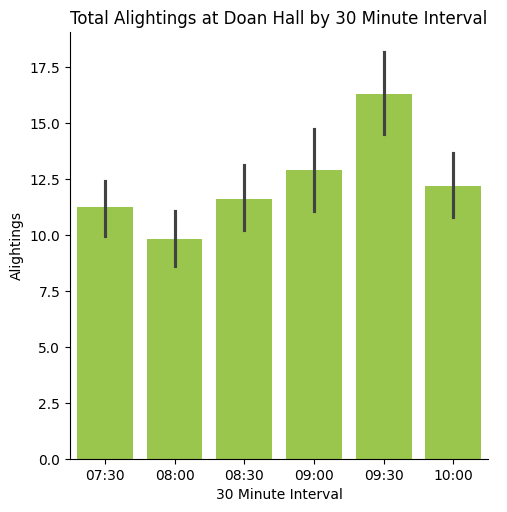

In [9]:
# plot Doan Hall individually
plot = sns.catplot(
    data = doan_df,
    x = 'BUCKET',
    y = 'ALIGHTINGS',
    kind = 'bar'
)
plot.set(title = "Total Alightings at Doan Hall by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Alightings")
plt.show()

### NOTES:

- Clear outbound traffic in this time interval. 
- Capacity seems to be mostly evenly distributed between alighting at UH and at Doan
- 9:30 hour is has the most capacity of alightings so far

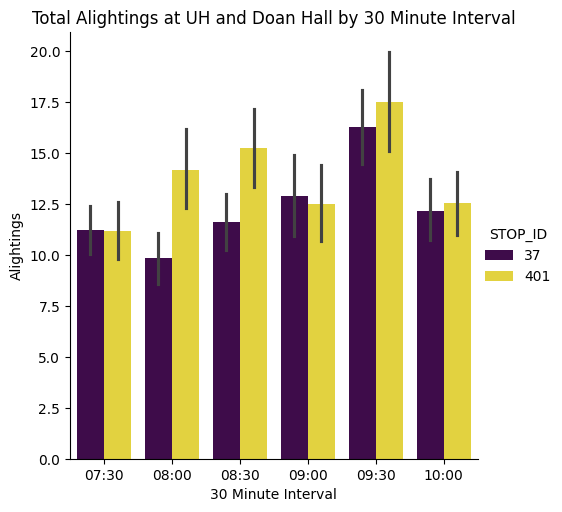

In [10]:
# Break apart boardings for UH and Doan Hall
plot = sns.catplot(
    data = mc_df,
    x = 'BUCKET',
    y = 'ALIGHTINGS',
    hue = 'STOP_ID',
    kind = 'bar',
    palette = "viridis"
)
plot.set(title = "Total Alightings at UH and Doan Hall by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Alightings")
plt.show()

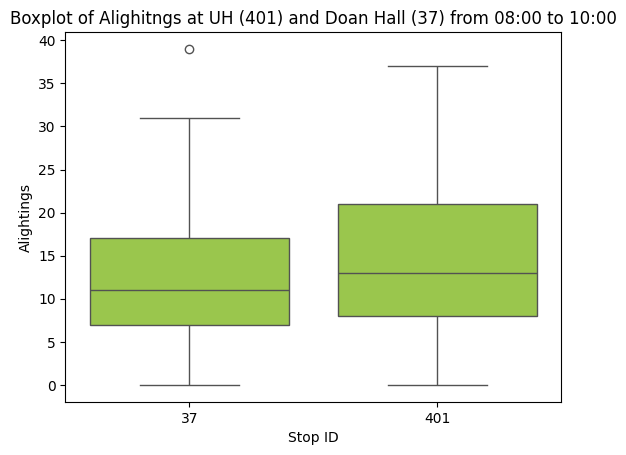

In [11]:
# quick outlier assessment
# cut down exactly to desired timeframe
temp = mc_df[(mc_df['TIME'].dt.time >= pd.to_datetime('08:00').time()) & (mc_df['TIME'].dt.time <= pd.to_datetime('10:00').time())]

sns.boxplot(data=temp, x='STOP_ID', y='ALIGHTINGS')
plt.title("Boxplot of Alighitngs at UH (401) and Doan Hall (37) from 08:00 to 10:00")
plt.xlabel("Stop ID")
plt.ylabel("Alightings")
plt.show()

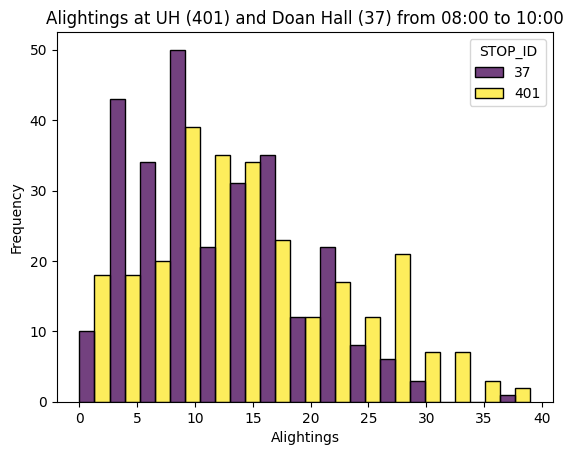

In [12]:
# Generate histogram of boardings at UH and Doan Hall from 14:00 to 16:00
sns.histplot(data=temp, x='ALIGHTINGS', hue='STOP_ID', multiple='dodge', palette="viridis")
plt.title("Alightings at UH (401) and Doan Hall (37) from 08:00 to 10:00")
plt.xlabel("Alightings")
plt.ylabel("Frequency")
plt.show()

### NOTES:
- Alightings in the morning are a lot less skewed than the boardings in the afternoon.
- 

In [13]:
# Look at the top quartile of alightings at each stop?

max_threshold_uh = 30 # choosing 3- for both to get a view of the top end of alightings
max_threshold_doan = 30

doan_outliers = temp[(temp['STOP_ID'] == 37) & (temp['ALIGHTINGS'] > max_threshold_doan)]
doan_outliers # only 1 outlier for Doan - not too concerned about this

,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,BUCKET,NET
5264,37,2,31,2026-04-06 08:09:34,08:00,-29
15670,37,2,39,2026-04-14 09:18:36,09:00,-37


In [14]:
uh_outliers = temp[(temp['STOP_ID'] == 401) & (temp['ALIGHTINGS'] > max_threshold_uh)]
uh_outliers

,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,BUCKET,NET
13624,401,5,37,2026-04-01 08:34:08,08:30,-32
13630,401,1,37,2026-04-01 08:55:45,08:30,-36
13865,401,2,31,2026-04-02 08:55:34,08:30,-29
14089,401,2,31,2026-04-03 08:12:01,08:00,-29
14101,401,0,34,2026-04-03 08:55:36,08:30,-34
5281,401,0,32,2026-04-06 09:16:47,09:00,-32
14471,401,3,34,2026-04-07 08:11:30,08:00,-31
14489,401,0,32,2026-04-07 09:19:36,09:00,-32
14495,401,2,32,2026-04-07 09:42:15,09:30,-30
6116,401,1,35,2026-04-09 08:53:28,08:30,-34


In [15]:
# Goal - get the context of these total outliers paired with the subsequent Doan Hall boardings
# Goal - get the context of these total outliers paired with the subsequent Doan Hall boardings
outlier_mask = (temp['STOP_ID'] == 401) & (temp['ALIGHTINGS'] > max_threshold_uh)
subsequent_doan_mask = (temp.index.isin(temp.index[outlier_mask] + 1)) & (temp['STOP_ID'] == 37)

total_outliers = temp[outlier_mask | subsequent_doan_mask].sort_index()
total_outliers.sort_values(by = 'TIME')

,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,BUCKET,NET
13624,401,5,37,2026-04-01 08:34:08,08:30,-32
13625,37,2,23,2026-04-01 08:35:23,08:30,-21
13630,401,1,37,2026-04-01 08:55:45,08:30,-36
13631,37,3,27,2026-04-01 08:56:54,08:30,-24
13865,401,2,31,2026-04-02 08:55:34,08:30,-29
13866,37,0,20,2026-04-02 08:56:31,08:30,-20
14089,401,2,31,2026-04-03 08:12:01,08:00,-29
14090,37,1,10,2026-04-03 08:14:07,08:00,-9
14101,401,0,34,2026-04-03 08:55:36,08:30,-34
14102,37,2,16,2026-04-03 08:57:51,08:30,-14


#### NOTES:
- There are very full busses sporadically from approximately **8:55am - 9:45am**
- The busses seem to be evenly alighting at both UH and Doan
    - This makes sense as people getting on at Carmack would not be separated by which stop they intend to get off at
    - Again, there is no way for me to say for sure that people are not waiting at for the next bus at carmack, etc.


In [16]:
# Going to see what the loading at Carmack stops looks like
apr_mc_df['STOP_ID'].value_counts()

STOP_ID
403    3301
404    3300
37     3278
401    3221
95     2732
94     2728
Name: count, dtype: int64

In [18]:
CARMACK_2 = 403
CARMACK_3 = 404
CARMACK_5A = 94
CARMACK_5B = 95

# Subsetting the Carmack stops to see total boardings
carmack_stop_ids = [CARMACK_2, CARMACK_3, CARMACK_5A, CARMACK_5B]
carmack_boardings_df = apr_mc_df[apr_mc_df['STOP_ID'].isin(carmack_stop_ids)]

carmack_boardings_df

,BUS_ID,DATE,COUNT,STOP_ID,BOARDINGS,ALIGHTINGS,LOAD,RUN_ID,DEST,ARRIVAL,DEPARTURE,DWELL,HOUR,MINUTE
0,1303,2026-04-01,1,403,3,0,3,1503.0,MC,1900-01-01 13:56:46,1900-01-01 13:57:22,0 days 00:00:36,13,56
1,1303,2026-04-01,2,404,2,0,5,1503.0,MC,1900-01-01 13:58:15,1900-01-01 13:58:45,0 days 00:00:30,13,58
2,1303,2026-04-01,3,94,2,0,7,1503.0,MC,1900-01-01 13:59:42,1900-01-01 14:00:15,0 days 00:00:33,13,59
3,1303,2026-04-01,4,95,0,0,7,1503.0,MC,1900-01-01 14:00:48,1900-01-01 14:01:06,0 days 00:00:18,14,0
6,1303,2026-04-01,7,403,9,11,30,1503.0,MC,1900-01-01 14:18:57,1900-01-01 14:20:16,0 days 00:01:19,14,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18553,2503,2026-04-14,18544,404,1,15,0,1507.0,MC,1900-01-01 19:42:21,1900-01-01 19:43:00,0 days 00:00:39,19,42
18554,2503,2026-04-14,18545,94,0,1,0,1507.0,MC,1900-01-01 19:43:52,1900-01-01 19:44:19,0 days 00:00:27,19,43
18555,2503,2026-04-14,18546,95,0,0,0,1507.0,MC,1900-01-01 19:44:50,1900-01-01 19:45:11,0 days 00:00:21,19,44
18558,2503,2026-04-14,18549,403,0,3,6,1507.0,I005,1900-01-01 19:58:16,1900-01-01 19:58:41,0 days 00:00:25,19,58


In [29]:
# cut down sample data to date, time of arrival, stop, boardings, and alightings 
temp = carmack_boardings_df[['DATE', 'ARRIVAL', 'STOP_ID', 'BOARDINGS', 'ALIGHTINGS']]

# combine date and arrival time to single col
temp['TIME'] = pd.to_datetime(temp['DATE'].astype(str) + ' ' + temp['ARRIVAL'].dt.time.astype(str))
temp.drop(['DATE', 'ARRIVAL'], axis=1, inplace=True)

# break apart timeframes into 30 min intervals - not keeping date specifically
# temp['BUCKET'] = temp['TIME'].dt.floor('30Min').dt.time

# cut down bucket to hr/min, dont need sec
# true 30-min bucket, no date shown
temp['BUCKET'] = temp['TIME'].dt.floor('30min').dt.strftime('%H:%M')

cm_mc_df = temp.copy()
cm_mc_df.sort_values(by='BUCKET', inplace=True)
cm_mc_df

,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,BUCKET
7394,95,0,0,2026-04-10 00:07:19,00:00
9133,404,0,1,2026-04-07 00:22:03,00:00
9134,94,0,2,2026-04-07 00:23:44,00:00
9135,95,0,0,2026-04-07 00:24:47,00:00
3539,403,0,0,2026-04-04 00:14:41,00:00
...,...,...,...,...,...
6885,403,0,0,2026-04-06 23:32:34,23:30
1987,95,0,0,2026-04-02 23:30:44,23:30
1990,403,0,3,2026-04-02 23:46:38,23:30
11630,95,1,4,2026-04-02 23:42:37,23:30


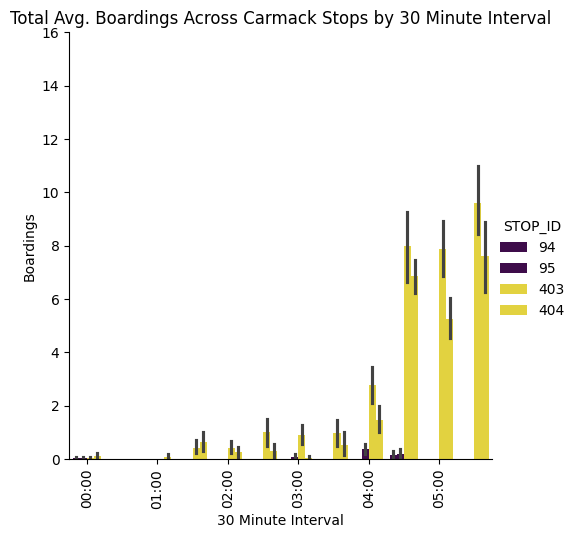

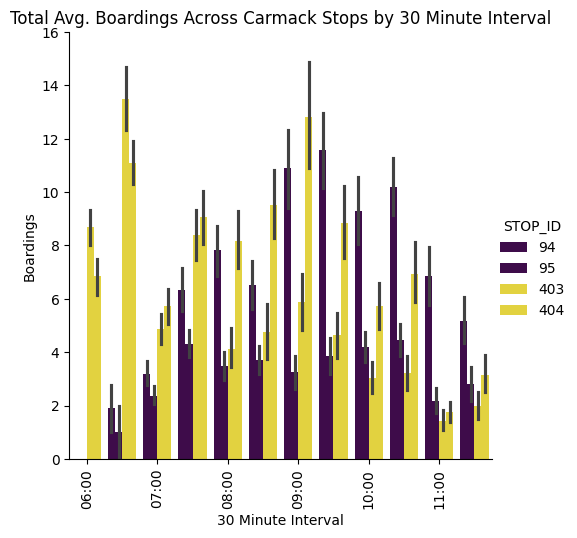

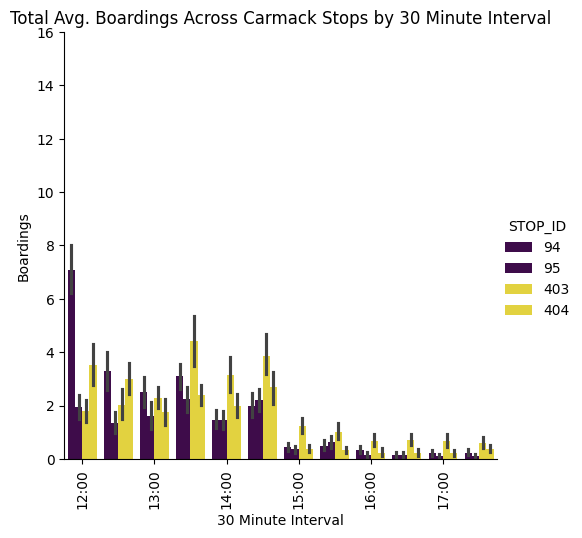

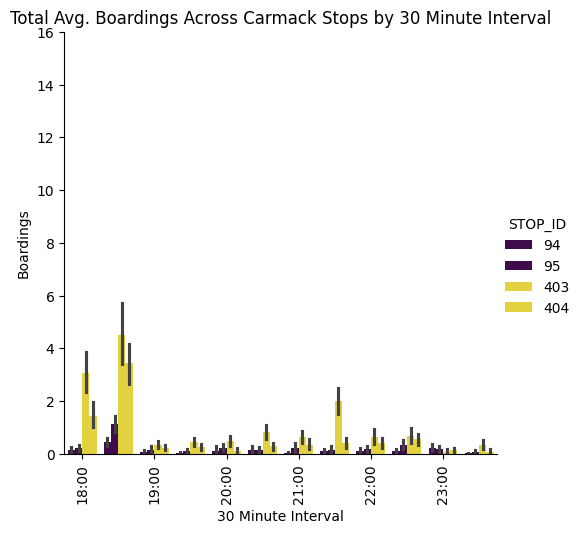

In [37]:
# Plot the average boardings at all 4 carmack stops by 30 min interval
# break apart into 4 plots across 6 hours each
# 0000 - 0600
cm_mc_df_0_6 = cm_mc_df[(cm_mc_df['TIME'].dt.time >= pd.to_datetime('00:00').time()) & (cm_mc_df['TIME'].dt.time < pd.to_datetime('06:00').time())] 

plot = sns.catplot(
    data = cm_mc_df_0_6,
    x = 'BUCKET',
    y = 'BOARDINGS',
    hue = 'STOP_ID',
    kind = 'bar',
    palette = "viridis"
)
plot.set(title = "Total Avg. Boardings Across Carmack Stops by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Boardings")
plt.ylim(0,16)
plt.xticks(rotation=90, ticks=range(0, len(cm_mc_df_0_6['BUCKET'].unique()), 2))
plt.show()

# 0600 - 1200
cm_mc_df_6_12 = cm_mc_df[(cm_mc_df['TIME'].dt.time >= pd.to_datetime('06:00').time()) & (cm_mc_df['TIME'].dt.time < pd.to_datetime('12:00').time())] 

plot = sns.catplot(
    data = cm_mc_df_6_12,
    x = 'BUCKET',
    y = 'BOARDINGS',
    hue = 'STOP_ID',
    kind = 'bar',
    palette = "viridis"
)
plot.set(title = "Total Avg. Boardings Across Carmack Stops by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Boardings")
plt.ylim(0,16)
plt.xticks(rotation=90, ticks=range(0, len(cm_mc_df_6_12['BUCKET'].unique()), 2))
plt.show()

# 1200 - 1800
cm_mc_df_12_18 = cm_mc_df[(cm_mc_df['TIME'].dt.time >= pd.to_datetime('12:00').time()) & (cm_mc_df['TIME'].dt.time < pd.to_datetime('18:00').time())] 

plot = sns.catplot(
    data = cm_mc_df_12_18,
    x = 'BUCKET',
    y = 'BOARDINGS',
    hue = 'STOP_ID',
    kind = 'bar',
    palette = "viridis"
)
plot.set(title = "Total Avg. Boardings Across Carmack Stops by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Boardings")
plt.ylim(0,16)
plt.xticks(rotation=90, ticks=range(0, len(cm_mc_df_12_18['BUCKET'].unique()), 2))
plt.show()

# 1800 - 0000
cm_mc_df_18_0 = cm_mc_df[(cm_mc_df['TIME'].dt.time >= pd.to_datetime('18:00').time()) & (cm_mc_df['TIME'].dt.time < pd.to_datetime('23:59').time())] 

plot = sns.catplot(
    data = cm_mc_df_18_0,
    x = 'BUCKET',
    y = 'BOARDINGS',
    hue = 'STOP_ID',
    kind = 'bar',
    palette = "viridis"
)
plot.set(title = "Total Avg. Boardings Across Carmack Stops by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Boardings")
plt.ylim(0,16)
plt.xticks(rotation=90, ticks=range(0, len(cm_mc_df_18_0['BUCKET'].unique()), 2))
plt.show()

### NOTES:
- 1900 -> 0500 has very little ridership 
- Small peal exists at 1800 for boardings
- Can see a relatively normal dist of both CM2/CM3 and CM5 with CM5 being offset, presumably due to CM2/CM3 lots filling up
- 

In [ ]:
# Total sums by 30-min bucket across all Carmack stops
bucket_totals = (
    cm_mc_df.groupby('BUCKET', as_index=False)[['BOARDINGS', 'ALIGHTINGS']]
    .sum()
    .sort_values('BUCKET')
)

bucket_totals

,BUCKET,BOARDINGS,ALIGHTINGS
0,00:00,7,50
1,00:30,0,41
2,01:00,2,70
3,01:30,15,41
4,02:00,19,12
5,02:30,18,18
6,03:00,27,33
7,03:30,37,26
8,04:00,179,17
9,04:30,600,12


<Axes: xlabel='STOP_ID', ylabel='BUCKET'>

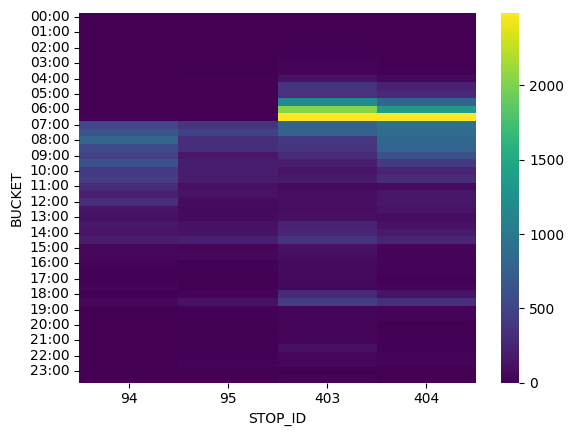

In [41]:
# Heatmap of boardings by stop and 30-min bucket
heatmap_data = cm_mc_df.pivot_table(index='BUCKET', columns='STOP_ID', values='BOARDINGS', aggfunc='sum').fillna(0)
sns.heatmap(heatmap_data, cmap='viridis')